<a href="https://colab.research.google.com/github/TetianaMar-888/Bank_Dataset_Machine_Learning_Project/blob/main/Marinoshenko_Tetiana_Mid_term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              f1_score,
                              precision_score,
                              recall_score,
                              confusion_matrix)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from typing import Tuple, Dict, Any
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score
import shap


pd.set_option('display.max.rows',150)
pd.set_option('display.max.columns',150)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Exploratory Data Analysis

In [3]:
df = pd.read_csv("drive/MyDrive/Colab Notebooks/bank-additional-full.csv", sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Пустих комірок немає. Пам'яті займає не багато.

In [4]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes


In [5]:
print("\n Наша цільова змінна 'y'")
print(df['y'].value_counts()) #The target variable is 'y' — whether the client subscribed to a term deposit
print("\n Статистичний звіт для числових змінних")
print(df.describe()) #Статистичний звіт для числових змінних
print("\n Назви категоріальних змінних")
print(df.select_dtypes(include = "object").columns) #назви категоріальних змінних
print("\n Кількість категоріальних змінних")
print(len(df.select_dtypes(include = "object").columns)) #кількість категоріальних змінних
print(df.shape)


 Наша цільова змінна 'y'
y
no     36548
yes     4640
Name: count, dtype: int64

 Статистичний звіт для числових змінних
           age  duration  campaign    pdays  previous  emp.var.rate  \
count 41188.00  41188.00  41188.00 41188.00  41188.00      41188.00   
mean     40.02    258.29      2.57   962.48      0.17          0.08   
std      10.42    259.28      2.77   186.91      0.49          1.57   
min      17.00      0.00      1.00     0.00      0.00         -3.40   
25%      32.00    102.00      1.00   999.00      0.00         -1.80   
50%      38.00    180.00      2.00   999.00      0.00          1.10   
75%      47.00    319.00      3.00   999.00      0.00          1.40   
max      98.00   4918.00     56.00   999.00      7.00          1.40   

       cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
count        41188.00       41188.00   41188.00     41188.00  
mean            93.58         -40.50       3.62      5167.04  
std              0.58           4.63       1.73   

In [6]:
print("\n Назви категоріальних змінних, що містять unknown")
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in unknown_cols:
    count = (df[col] == 'unknown').sum()
    pct = count / len(df) * 100
    print(f"{col:12}: {count:5} ({pct:.2f}%)")


 Назви категоріальних змінних, що містять unknown
job         :   330 (0.80%)
marital     :    80 (0.19%)
education   :  1731 (4.20%)
default     :  8597 (20.87%)
housing     :   990 (2.40%)
loan        :   990 (2.40%)


Спостереження

Присутній дисбаланс класів в цільовій змінній.
Атрибут pdays max=999 - означає, що майже всі клієнти нові та не мали контакту з банком з минулої кампанії.
Колонку duration перед розподілом даних потрібно буде видалити.
Категоріальні колонки, що містять unknown (job, marital, education, default, housing, loan) - потрібно буде замінити модою чи медіаною.

На мою думку вплив на розміщення депозиту мають категорії : освіта, зайнятість, вік та економічні індикатори.

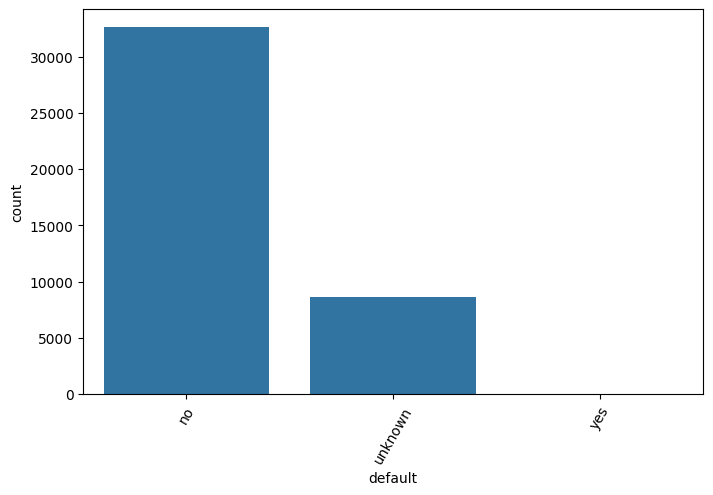

In [ ]:
# Візуалізуємо колонку чи є наявні протерміновані кредити
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = "default")
plt.xticks(rotation = 60)
plt.show()

In [ ]:
df.default.value_counts()

,count
default,
no,32588
unknown,8597
yes,3


In [ ]:
df.default.mode()[0]

'no'

#Preprocessing

In [ ]:
numeric_cols = df.select_dtypes(include = np.number).columns.tolist()
print(numeric_cols)
categorical_cols = df.select_dtypes(include = 'object').columns.tolist()
print(categorical_cols)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


Спостереження

default заповнити модою, або взагалі видалити колонку.

Я вирішую залишити колонку default, так як вона важлива, на мій погляд, для прогнозу. Тому, що вона показує, що в людей немає протермінованих кредитів. А, це важлива складова для розміщення депозиту. А, unknown означає, що в цих клієнтів дана інформація не перевірена.

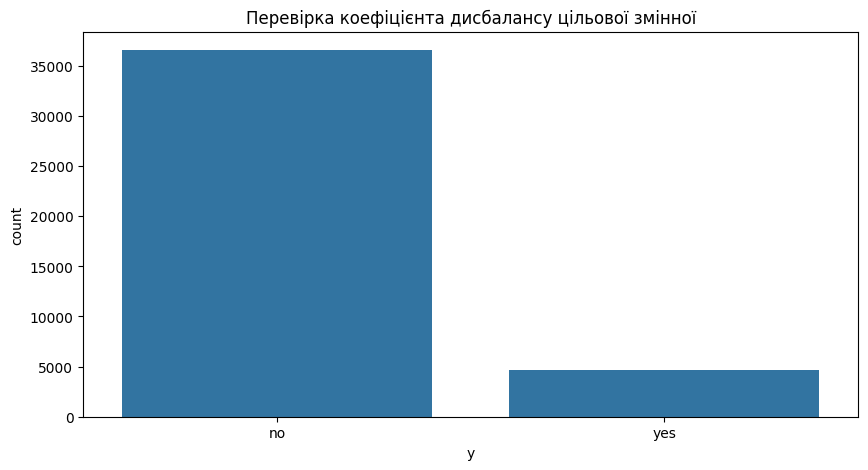

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(x = df['y'], data = df)
plt.title('Перевірка коефіцієнта дисбалансу цільової змінної')
plt.show()

In [ ]:
#Замінюємо 'unknown' на NaN і заповнюємо модою
fill_cols = ['job', 'marital', 'education', 'housing', 'loan']
df[fill_cols] = df[fill_cols].replace('unknown', np.nan)

for col in fill_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df[fill_cols].isin(['unknown']).sum())

job          0
marital      0
education    0
housing      0
loan         0
dtype: int64


In [ ]:
#Зберігаю окремо колонку duration і видаляю з загального датасету
duration_series = df['duration'].copy()
df = df.drop(columns=['duration'])

In [ ]:
duration_test = duration_series.iloc[X_test.index]
print("duration_test створено:", duration_test.shape)

duration_test створено: (12357,)


In [ ]:
#Перевірка на Outliers
num_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Метод IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col:20}: {len(outliers):5} викидів ({len(outliers)/len(df)*100:.1f}%)")

age                 :   469 викидів (1.1%)
campaign            :  2406 викидів (5.8%)
previous            :  5625 викидів (13.7%)
emp.var.rate        :     0 викидів (0.0%)
cons.price.idx      :     0 викидів (0.0%)
cons.conf.idx       :   447 викидів (1.1%)
euribor3m           :     0 викидів (0.0%)
nr.employed         :     0 викидів (0.0%)


Спостереження:

Видалення викидів не потрібне — всі значення мають реальний економічний або бізнес сенс.

In [ ]:
#колонку pdays замінюю на колонку "чи контактували взагалі". Тому що майже 96% клієнтів не контактували з банком раніше
df['was_contacted'] = (df['pdays'] != 999).astype(int)

In [ ]:
# Робимо Encode цільової змінної
df['y'] = (df['y'] == 'yes').astype(int)
print(df['y'].value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


In [ ]:
df[categorical_cols].nunique()

,0
job,11
marital,3
education,7
default,3
housing,2
loan,2
contact,2
month,10
day_of_week,5
poutcome,3


In [ ]:
#Робимо One-Hot Encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Категоріальні колонки:", cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df.shape)

Категоріальні колонки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
(41188, 49)


In [ ]:
#Ділимо дані
train_val_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['y'])
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df['y'])

print('train_df.shape :', train_df.shape)
print('val_df.shape   :', val_df.shape)
print('test_df.shape  :', test_df.shape)

train_df.shape : (21623, 49)
val_df.shape   : (7208, 49)
test_df.shape  : (12357, 49)


In [ ]:
# Перевірка балансу класів у кожній вибірці
print("\nБаланс класів:")
print("Train:", train_df['y'].value_counts(normalize=True).round(3))
print("Val:  ", val_df['y'].value_counts(normalize=True).round(3))
print("Test: ", test_df['y'].value_counts(normalize=True).round(3))


Баланс класів:
Train: y
0   0.89
1   0.11
Name: proportion, dtype: float64
Val:   y
0   0.89
1   0.11
Name: proportion, dtype: float64
Test:  y
0   0.89
1   0.11
Name: proportion, dtype: float64


In [ ]:
#визначаємо X та y
X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_val = val_df.drop(columns=['y'])
y_val = val_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']

print(X_train.shape, X_val.shape, X_test.shape)

(21623, 48) (7208, 48) (12357, 48)


In [ ]:
# SMOTE тільки на train
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("До SMOTE:  ", y_train.value_counts())
print("Після SMOTE:", y_train_res.value_counts())
print("Нова форма X_train_res:", X_train_res.shape)

До SMOTE:   y
0    19187
1     2436
Name: count, dtype: int64
Після SMOTE: y
0    19187
1    19187
Name: count, dtype: int64
Нова форма X_train_res: (38374, 48)


In [ ]:
scaler = StandardScaler()

# fit тільки на train після SMOTE
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:  ", X_val_scaled.shape)
print("X_test_scaled: ", X_test_scaled.shape)

X_train_scaled: (38374, 48)
X_val_scaled:   (7208, 48)
X_test_scaled:  (12357, 48)


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/data/'
os.makedirs(path, exist_ok=True)

# Scaled дані (для LR та kNN)
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_parquet(path + 'X_train_scaled.parquet')
pd.DataFrame(X_val_scaled,   columns=X_val.columns).to_parquet(path + 'X_val_scaled.parquet')
pd.DataFrame(X_test_scaled,  columns=X_test.columns).to_parquet(path + 'X_test_scaled.parquet')

# Не scaled дані (для DT та XGBoost)
X_train_res.to_parquet(path + 'X_train_res.parquet')
X_val.to_parquet(path + 'X_val.parquet')
X_test.to_parquet(path + 'X_test.parquet')

# Таргети
y_train_res.to_frame().to_parquet(path + 'y_train_res.parquet')
y_val.to_frame().to_parquet(path + 'y_val.parquet')
y_test.to_frame().to_parquet(path + 'y_test.parquet')

# Duration для аналізу
duration_test.to_frame().to_parquet(path + 'duration_test.parquet')

print("Збережено файли:")
for f in sorted(os.listdir(path)):
    print(f"  ✅ {f}")

Збережено файли:
  ✅ X_test.parquet
  ✅ X_test_scaled.parquet
  ✅ X_train_res.parquet
  ✅ X_train_scaled.parquet
  ✅ X_val.parquet
  ✅ X_val_scaled.parquet
  ✅ duration_test.parquet
  ✅ y_test.parquet
  ✅ y_train_res.parquet
  ✅ y_val.parquet


Для оцінки моделей я використовую декілька метрик, щоб отримати більш "чесніші" показники роботи моделей через дисбаланс класів.

ROC-AUC — показує загальну здатність розділяти класи, але не говорить про конкретний поріг.

F1 — баланс між Precision та Recall, важливо коли присутній дисбаланс класів (в нас саме такий датасет).
Claude підказує, що у банківському маркетингу зазвичай важливіший Recall — краще зателефонувати зайвий раз, ніж пропустити клієнта який готовий відкрити депозит.

Тому зараз будемо перевіряти

In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/data/'

# Scaled дані (для LR та kNN)
X_train_scaled = pd.read_parquet(path + 'X_train_scaled.parquet').values
X_val_scaled   = pd.read_parquet(path + 'X_val_scaled.parquet').values
X_test_scaled  = pd.read_parquet(path + 'X_test_scaled.parquet').values

# Не scaled дані (для DT та XGBoost)
X_train_res = pd.read_parquet(path + 'X_train_res.parquet')
X_val       = pd.read_parquet(path + 'X_val.parquet')
X_test      = pd.read_parquet(path + 'X_test.parquet')

# Таргети
y_train_res = pd.read_parquet(path + 'y_train_res.parquet')['y']
y_val       = pd.read_parquet(path + 'y_val.parquet')['y']
y_test      = pd.read_parquet(path + 'y_test.parquet')['y']

# Duration для аналізу
duration_test = pd.read_parquet(path + 'duration_test.parquet')['duration']

print("Дані завантажено!")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Дані завантажено!
X_train_scaled: (38374, 48)
X_val_scaled:   (7208, 48)
X_test_scaled:  (12357, 48)


In [4]:
#Виношу в функцію оцінки моделей для зручності перевірки та подальшого порівняння моделей
def evaluate_model(model_name, y_true, y_pred, y_proba):
    print("=" * 40)
    print(f"  {model_name}")
    print("=" * 40)
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"\n{classification_report(y_true, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")

#Тренуємо модель Logistic Regression

In [5]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_res)

y_val_pred = lr.predict(X_val_scaled)
y_val_proba = lr.predict_proba(X_val_scaled)[:, 1]

evaluate_model("Logistic Regression — Validation", y_val, y_val_pred, y_val_proba)

  Logistic Regression — Validation
ROC-AUC  : 0.7094
F1-Score : 0.3642
Precision: 0.3284
Recall   : 0.4089

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      6396
           1       0.33      0.41      0.36       812

    accuracy                           0.84      7208
   macro avg       0.63      0.65      0.64      7208
weighted avg       0.86      0.84      0.85      7208

Confusion Matrix:
[[5717  679]
 [ 480  332]]


Спостереження

Модель занадто консервативна — частіше каже "no"
Recall = 0.41 — пропускає 59% потенційних клієнтів
Precision = 0.33 — з кожних 3 передбачених "yes" — 2 помилкові

#Тренуємо модель kNN

In [6]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train_res)

y_val_pred_knn  = knn.predict(X_val_scaled)
y_val_proba_knn = knn.predict_proba(X_val_scaled)[:, 1]

evaluate_model("kNN — Validation", y_val, y_val_pred_knn, y_val_proba_knn)

  kNN — Validation
ROC-AUC  : 0.7246
F1-Score : 0.3691
Precision: 0.3113
Recall   : 0.4532

              precision    recall  f1-score   support

           0       0.93      0.87      0.90      6396
           1       0.31      0.45      0.37       812

    accuracy                           0.83      7208
   macro avg       0.62      0.66      0.63      7208
weighted avg       0.86      0.83      0.84      7208

Confusion Matrix:
[[5582  814]
 [ 444  368]]


Спостереження:

Модель майже однакова за якістю з Logistic Regression.

kNN знаходить трохи більше реальних клієнтів (Recall вищий) — 368 vs 332

LR менше хибних тривог (Precision вищий) — 679 vs 814 зайвих дзвінків.
Але обидві моделі поки слабо працюють з класом "yes".

Я спочатку взяла n_neighbors=5, то знайшло трохи менше нових клієнтів, але зробила модель прогноз на меншу кількість хибних дзвінків.

#Тренуємо модель Decision Tree

In [7]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_res, y_train_res)


dt_train_roc = round(roc_auc_score(y_train_res, dt_default.predict_proba(X_train_res)[:, 1]), 2)
dt_train_f1  = round(f1_score(y_train_res, dt_default.predict(X_train_res)), 2)
print(f"DT Train ROC-AUC: {dt_train_roc}")
print(f"DT Train F1:      {dt_train_f1}")


y_val_pred_dt  = dt_default.predict(X_val)
y_val_proba_dt = dt_default.predict_proba(X_val)[:, 1]

evaluate_model("Decision Tree — Validation", y_val, y_val_pred_dt, y_val_proba_dt)

DT Train ROC-AUC: 1.0
DT Train F1:      1.0
  Decision Tree — Validation
ROC-AUC  : 0.6277
F1-Score : 0.3209
Precision: 0.2774
Recall   : 0.3805

              precision    recall  f1-score   support

           0       0.92      0.87      0.90      6396
           1       0.28      0.38      0.32       812

    accuracy                           0.82      7208
   macro avg       0.60      0.63      0.61      7208
weighted avg       0.85      0.82      0.83      7208

Confusion Matrix:
[[5591  805]
 [ 503  309]]


Спостереження:

Decision Tree (default) - ROC-AUC Train та F1 Train = 1.00 - ідеальне перенавчання. Модель просто запам'ятала весь тренувальний датасет.
Дерево росте до кінця і погано генералізує на нових даних. В порівнянні з попередніми моделями показує найнижчі результати.

Спробуємо обмежити глибину.

In [8]:
dt_depth5 = DecisionTreeClassifier(random_state=42, max_depth=5) #обмежуємо глибину max_depth=5
dt_depth5.fit(X_train_res, y_train_res)

dt_train_roc = round(roc_auc_score(y_train_res, dt_depth5.predict_proba(X_train_res)[:, 1]), 4)
dt_train_f1  = round(f1_score(y_train_res, dt_depth5.predict(X_train_res)), 4)
print(f"DT Train ROC-AUC: {dt_train_roc}")
print(f"DT Train F1:      {dt_train_f1}")

y_val_pred_dt  = dt_depth5.predict(X_val)
y_val_proba_dt = dt_depth5.predict_proba(X_val)[:, 1]

evaluate_model("Decision Tree — Validation", y_val, y_val_pred_dt, y_val_proba_dt)

DT Train ROC-AUC: 0.8351
DT Train F1:      0.7648
  Decision Tree — Validation
ROC-AUC  : 0.7454
F1-Score : 0.4495
Precision: 0.3747
Recall   : 0.5616

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      6396
           1       0.37      0.56      0.45       812

    accuracy                           0.85      7208
   macro avg       0.66      0.72      0.68      7208
weighted avg       0.88      0.85      0.86      7208

Confusion Matrix:
[[5635  761]
 [ 356  456]]


Спостереження:

max_depth=5 дав величезне покращення — регуляризація допомогла дереву не перенавчатись.

Тому спостерігаємо найкращий результат навчання моделі в порівнянні з попередніми.

Recall - 456(нові клієнти) - є поки кращим показником за всі попередні моделі. Precision (хибні спроби) - 761 (найкращий показник в LR поки що).

Train ROC-AUC: 0.84 vs Val ROC-AUC: 0.75 → різниця 0.09 Train F1: 0.76 vs Val F1: 0.45 → різниця 0.31 - часткове перенавчання. Набагато гірше працює на нових даних

In [9]:
#обмежуємо глибину max_depth=3
dt_depth3 = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_depth3.fit(X_train_res, y_train_res)

dt_train_roc = round(roc_auc_score(y_train_res, dt_depth3.predict_proba(X_train_res)[:, 1]), 4)
dt_train_f1  = round(f1_score(y_train_res, dt_depth3.predict(X_train_res)), 4)
print(f"DT Train ROC-AUC: {dt_train_roc}")
print(f"DT Train F1:      {dt_train_f1}")

y_val_pred_dt  = dt_depth3.predict(X_val)
y_val_proba_dt = dt_depth3.predict_proba(X_val)[:, 1]

evaluate_model("Decision Tree — Validation", y_val, y_val_pred_dt, y_val_proba_dt)

DT Train ROC-AUC: 0.7885
DT Train F1:      0.7027
  Decision Tree — Validation
ROC-AUC  : 0.7509
F1-Score : 0.4483
Precision: 0.3549
Recall   : 0.6084

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      6396
           1       0.35      0.61      0.45       812

    accuracy                           0.83      7208
   macro avg       0.65      0.73      0.67      7208
weighted avg       0.88      0.83      0.85      7208

Confusion Matrix:
[[5498  898]
 [ 318  494]]


Спостереження:

DT3 знаходить 855 клієнтів (61%), що більше ніж при DT5

Але DT5 — Вищий Precision

#Тренуємо модель XGBoost

In [10]:
xgb_default = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_default.fit(X_train_res, y_train_res)

y_val_pred_xgb  = xgb_default.predict(X_val)
y_val_proba_xgb = xgb_default.predict_proba(X_val)[:, 1]

evaluate_model("XGBoost — Validation", y_val, y_val_pred_xgb, y_val_proba_xgb)

  XGBoost — Validation
ROC-AUC  : 0.7664
F1-Score : 0.4187
Precision: 0.4750
Recall   : 0.3744

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6396
           1       0.47      0.37      0.42       812

    accuracy                           0.88      7208
   macro avg       0.70      0.66      0.68      7208
weighted avg       0.87      0.88      0.88      7208

Confusion Matrix:
[[6060  336]
 [ 508  304]]


Спостереження:

XGBoost — найкраща модель в ROC-AUC та Precision:

Найменше хибних тривог (336)
Але Recall низький — пропускає багато клієнтів (508). А, нові клієнти з їхніми депозитами - це і є основною метою навчання моделей.

#Для алгоритму XGBoost виконуємо тюнинг гіперпараметрів

In [11]:
#Sklearn: Randomized Search
param_dist_xgb = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(3, 6),        # обмежуємо до 6 як у Bayesian, тому що попередній варіант з глибиною 9 не покращив якість моделі. Дерево глибоке.
    'learning_rate'   : uniform(0.01, 0.29),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma'           : uniform(0, 0.5),      # додаємо регуляризацію
    'reg_alpha'       : uniform(0, 1),
    'reg_lambda'      : uniform(0, 1)
}

random_xgb_v2 = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_xgb_v2.fit(X_train_res, y_train_res)

print("Найкращі параметри (Random v2):", random_xgb_v2.best_params_)
print("Найкращий ROC-AUC (CV):", round(random_xgb_v2.best_score_, 4))

y_val_pred_random_v2  = random_xgb_v2.best_estimator_.predict(X_val)
y_val_proba_random_v2 = random_xgb_v2.best_estimator_.predict_proba(X_val)[:, 1]

evaluate_model("XGBoost RandomizedSearch v2 — Validation", y_val, y_val_pred_random_v2, y_val_proba_random_v2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Найкращі параметри (Random v2): {'colsample_bytree': np.float64(0.6931085361721216), 'gamma': np.float64(0.0453032172664104), 'learning_rate': np.float64(0.1893319427065953), 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 419, 'reg_alpha': np.float64(0.4667628932479799), 'reg_lambda': np.float64(0.8599404067363206), 'subsample': np.float64(0.8721230154351118)}
Найкращий ROC-AUC (CV): 0.9685
  XGBoost RandomizedSearch v2 — Validation
ROC-AUC  : 0.7644
F1-Score : 0.4093
Precision: 0.4793
Recall   : 0.3571

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      6396
           1       0.48      0.36      0.41       812

    accuracy                           0.88      7208
   macro avg       0.70      0.65      0.67      7208
weighted avg       0.87      0.88      0.88      7208

Confusion Matrix:
[[6081  315]
 [ 522  290]]


Спостереження

max_depth=5. Найкращий ROC-AUC (CV) 0.97 на трейні та 0.76 на валідації - це 0.22 різниці, що говорить про перенавчання (так само як і при max_depth=9). Тобто, тюнінг гіперпараметрів алгоритму не покращив роботи моделі.

In [12]:
# #Hyperopt:Bayesian Optimization
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators      = int(params['n_estimators']),
        learning_rate     = params['learning_rate'],
        max_depth         = int(params['max_depth']),
        min_child_weight  = int(params['min_child_weight']),
        subsample         = params['subsample'],
        colsample_bytree  = params['colsample_bytree'],
        gamma             = params['gamma'],
        reg_alpha         = params['reg_alpha'],
        reg_lambda        = params['reg_lambda'],
        eval_metric       = 'logloss',
        random_state      = 42
    )

    clf.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_proba = clf.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_val_proba)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators'    : hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate'   : hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth'       : hp.quniform('max_depth', 3, 6, 1),      # обмежуємо до 6
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample'       : hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma'           : hp.uniform('gamma', 0, 0.5),
    'reg_alpha'       : hp.uniform('reg_alpha', 0, 1),
    'reg_lambda'      : hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(
    fn       = objective,
    space    = space,
    algo     = tpe.suggest,
    max_evals= 50,
    trials   = trials
)

# Перетворення типів
best['n_estimators']     = int(best['n_estimators'])
best['max_depth']        = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри:", best)

# Навчання фінальної моделі
xgb_tuned = xgb.XGBClassifier(
    n_estimators      = best['n_estimators'],
    learning_rate     = best['learning_rate'],
    max_depth         = best['max_depth'],
    min_child_weight  = best['min_child_weight'],
    subsample         = best['subsample'],
    colsample_bytree  = best['colsample_bytree'],
    gamma             = best['gamma'],
    reg_alpha         = best['reg_alpha'],
    reg_lambda        = best['reg_lambda'],
    eval_metric       = 'logloss',
    random_state      = 42
)

xgb_tuned.fit(X_train_res, y_train_res)

# Оцінка на валідації
y_val_pred_tuned  = xgb_tuned.predict(X_val)
y_val_proba_tuned = xgb_tuned.predict_proba(X_val)[:, 1]

evaluate_model("XGBoost Hyperopt Tuned — Validation", y_val, y_val_pred_tuned, y_val_proba_tuned)

100%|██████████| 50/50 [01:41<00:00,  2.04s/trial, best loss: -0.7788516414199762]
Найкращі гіперпараметри: {'colsample_bytree': np.float64(0.9898692673748243), 'gamma': np.float64(0.27488091884294985), 'learning_rate': np.float64(0.06128160949988187), 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': np.float64(0.9146054859196686), 'reg_lambda': np.float64(0.3812342031427578), 'subsample': np.float64(0.9568381337562444)}
  XGBoost Hyperopt Tuned — Validation
ROC-AUC  : 0.7789
F1-Score : 0.4403
Precision: 0.4657
Recall   : 0.4175

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6396
           1       0.47      0.42      0.44       812

    accuracy                           0.88      7208
   macro avg       0.70      0.68      0.69      7208
weighted avg       0.88      0.88      0.88      7208

Confusion Matrix:
[[6007  389]
 [ 473  339]]


Спостереження:

Гіперпараметри: gamma, reg_alpha, reg_lambda покращили модель значно. Зробили кращу регуляризацію ніж без них.

RandomizedSearch — випадковий перебір — не вчиться на попередніх спробах.

Bayesian — розумний пошук — кожна наступна спроба враховує попередні результати.

#Порівняння якості моделей

In [18]:
data = {
    'Модель': [
        'Logistic Regression',
        'kNN',
        'Decision Tree (default)',
        'Decision Tree (max_depth=5)',
        'Decision Tree (max_depth=3)',
        'XGBoost (default)',
        'XGBoost (RandomizedSearch)',
        'XGBoost (Bayesian)'
    ],
    'Гіперпараметри': [
        'max_iter=1000, C=1.0',
        'n_neighbors=5',
        'default',
        'max_depth=5',
        'max_depth=3',
        'default',
        'max_depth=5, n_estimators=419, lr=0.189, gamma=0.045, reg_alpha=0.467, reg_lambda=0.860',
        'max_depth=5, n_estimators=325, lr=0.054, gamma=0.283, reg_alpha=0.337, reg_lambda=0.398'
    ],
    'ROC-AUC Train': [
        round(roc_auc_score(y_train_res, lr.predict_proba(X_train_scaled)[:, 1]), 4),
        round(roc_auc_score(y_train_res, knn.predict_proba(X_train_scaled)[:, 1]), 4),
        round(roc_auc_score(y_train_res, dt_default.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, dt_depth5.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, dt_depth3.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, xgb_default.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, random_xgb_v2.best_estimator_.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, xgb_tuned.predict_proba(X_train_res)[:, 1]), 4)
    ],
    'ROC-AUC Val': [0.7094, 0.7108, 0.6277, 0.7454, 0.7509, 0.7664, 0.7644, 0.7772],
    'F1 Train': [
        round(f1_score(y_train_res, lr.predict(X_train_scaled)), 4),
        round(f1_score(y_train_res, knn.predict(X_train_scaled)), 4),
        round(f1_score(y_train_res, dt_default.predict(X_train_res)), 4),
        round(f1_score(y_train_res, dt_depth5.predict(X_train_res)), 4),
        round(f1_score(y_train_res, dt_depth3.predict(X_train_res)), 4),
        round(f1_score(y_train_res, xgb_default.predict(X_train_res)), 4),
        round(f1_score(y_train_res, random_xgb_v2.best_estimator_.predict(X_train_res)), 4),
        round(f1_score(y_train_res, xgb_tuned.predict(X_train_res)), 4)
    ],
    'F1 Val':        [0.3642, 0.3591, 0.3209, 0.4495, 0.4483, 0.4187, 0.4093, 0.4374],
    'Precision Val': [0.3284, 0.3059, 0.2774, 0.3747, 0.3549, 0.4750, 0.4793, 0.4593],
    'Recall Val':    [0.4089, 0.4347, 0.3805, 0.5616, 0.6084, 0.3744, 0.3571, 0.4175],
    'Коментар': [
        'Слабкий F1, низький Recall. Базова лінія',
        'Схожий на LR, повільний на великих даних',
        'Перенавчання — не використовувати',
        'Хороший Recall, помірне перенавчання',
        'Найкращий Recall, мінімальне перенавчання',
        'Хороший базовий XGBoost',
        'Покращена регуляризація, але Recall низький',
        'Найкращий ROC-AUC та F1 '
    ]
}

df_results = pd.DataFrame(data)
df_results

,Модель,Гіперпараметри,ROC-AUC Train,ROC-AUC Val,F1 Train,F1 Val,Precision Val,Recall Val,Коментар
0,Logistic Regression,"max_iter=1000, C=1.0",0.93,0.71,0.86,0.36,0.33,0.41,"Слабкий F1, низький Recall. Базова лінія"
1,kNN,n_neighbors=5,0.98,0.71,0.92,0.36,0.31,0.43,"Схожий на LR, повільний на великих даних"
2,Decision Tree (default),default,1.00,0.63,1.00,0.32,0.28,0.38,Перенавчання — не використовувати
3,Decision Tree (max_depth=5),max_depth=5,0.84,0.75,0.76,0.45,0.37,0.56,"Хороший Recall, помірне перенавчання"
4,Decision Tree (max_depth=3),max_depth=3,0.79,0.75,0.70,0.45,0.35,0.61,"Найкращий Recall, мінімальне перенавчання"
5,XGBoost (default),default,0.98,0.77,0.94,0.42,0.47,0.37,Хороший базовий XGBoost
6,XGBoost (RandomizedSearch),"max_depth=5, n_estimators=419, lr=0.189, gamma...",0.99,0.76,0.95,0.41,0.48,0.36,"Покращена регуляризація, але Recall низький"
7,XGBoost (Bayesian),"max_depth=5, n_estimators=325, lr=0.054, gamma...",0.97,0.78,0.91,0.44,0.46,0.42,Найкращий ROC-AUC та F1


In [ ]:
%whos

#Дзвінки

In [ ]:
print(type(duration_series))
print(duration_series.shape)
print(duration_series.head())

<class 'pandas.core.series.Series'>
(41188,)
0    261
1    149
2    226
3    151
4    307
Name: duration, dtype: int64


In [ ]:
duration_test = pd.read_parquet(path + 'duration_test.parquet')['duration']
print(duration_test.shape)
print(duration_test.head())

(12357,)
9923      41
3477     151
12077    397
1579     180
39993    665
Name: duration, dtype: int64


In [13]:
# Фінальний тест — XGBoost (Bayesian)
y_test_pred_xgb  = xgb_tuned.predict(X_test)
y_test_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost Bayesian — TEST", y_test, y_test_pred_xgb, y_test_proba_xgb)

# Фінальний тест — Decision Tree (max_depth=3)
y_test_pred_dt  = dt_depth3.predict(X_test)
y_test_proba_dt = dt_depth3.predict_proba(X_test)[:, 1]
evaluate_model("Decision Tree (max_depth=3) — TEST", y_test, y_test_pred_dt, y_test_proba_dt)

  XGBoost Bayesian — TEST
ROC-AUC  : 0.7866
F1-Score : 0.4646
Precision: 0.5059
Recall   : 0.4296

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     10965
           1       0.51      0.43      0.46      1392

    accuracy                           0.89     12357
   macro avg       0.72      0.69      0.70     12357
weighted avg       0.88      0.89      0.88     12357

Confusion Matrix:
[[10381   584]
 [  794   598]]
  Decision Tree (max_depth=3) — TEST
ROC-AUC  : 0.7579
F1-Score : 0.4600
Precision: 0.3677
Recall   : 0.6142

              precision    recall  f1-score   support

           0       0.95      0.87      0.90     10965
           1       0.37      0.61      0.46      1392

    accuracy                           0.84     12357
   macro avg       0.66      0.74      0.68     12357
weighted avg       0.88      0.84      0.85     12357

Confusion Matrix:
[[9495 1470]
 [ 537  855]]


In [14]:
y_test_pred_dt3  = dt_depth3.predict(X_test)
y_test_pred_dt5  = dt_depth5.predict(X_test)
y_test_pred_xgb  = xgb_tuned.predict(X_test)

results_df = pd.DataFrame({
    'y_true'     : y_test.values,
    'y_pred_xgb' : y_test_pred_xgb,       # XGBoost (Bayesian)
    'y_pred_dt3' : y_test_pred_dt3,        # DT (max_depth=3)
    'y_pred_dt5' : y_test_pred_dt,         # DT (max_depth=5)
    'duration'   : duration_test.values
})

print("Середня тривалість дзвінка по класах:")
print(results_df.groupby('y_true')['duration'].mean().round(1))

print("\nXGBoost — тривалість по передбаченнях:")
print(results_df.groupby('y_pred_xgb')['duration'].mean().round(1))

Середня тривалість дзвінка по класах:
y_true
0   222.50
1   551.40
Name: duration, dtype: float64

XGBoost — тривалість по передбаченнях:
y_pred_xgb
0   256.30
1   289.70
Name: duration, dtype: float64


In [ ]:
results_df.head()

Яка модель краще знаходить довгі дзвінки:

In [15]:
# Простий бізнес-поріг на основі duration
threshold = 500  # секунд

long_calls = results_df[results_df['duration'] > threshold]

print("=== Дзвінки > 500 сек ===")
print(f"Всього: {len(long_calls)}, з них депозит: {long_calls['y_true'].sum()}")
print(f"Конверсія: {long_calls['y_true'].mean()*100:.1f}%")

print("\nXGBoost (Bayesian):")
print(f"  Знайшов 'yes': {long_calls['y_pred_xgb'].sum()}")
print(f"  Пропустив:     {(long_calls['y_true']==1).sum() - ((long_calls['y_true']==1) & (long_calls['y_pred_xgb']==1)).sum()}")

print("\nDecision Tree (max_depth=3):")
print(f"  Знайшов 'yes': {long_calls['y_pred_dt3'].sum()}")
print(f"  Пропустив:     {(long_calls['y_true']==1).sum() - ((long_calls['y_true']==1) & (long_calls['y_pred_dt3']==1)).sum()}")

print("\nDecision Tree (max_depth=5):")
print(f"  Знайшов 'yes': {long_calls['y_pred_dt5'].sum()}")
print(f"  Пропустив:     {(long_calls['y_true']==1).sum() - ((long_calls['y_true']==1) & (long_calls['y_pred_dt5']==1)).sum()}")

=== Дзвінки > 500 сек ===
Всього: 1493, з них депозит: 600
Конверсія: 40.2%

XGBoost (Bayesian):
  Знайшов 'yes': 150
  Пропустив:     497

Decision Tree (max_depth=3):
  Знайшов 'yes': 308
  Пропустив:     430

Decision Tree (max_depth=5):
  Знайшов 'yes': 308
  Пропустив:     430


Спостереження:

DT (max_depth=3) та DT (max_depth=5) дають однаковий результат на довгих дзвінках — 308 знайдених клієнтів. Це означає що перші 3 рівні дерева вже вловлюють весь корисний сигнал для цієї групи клієнтів.

In [16]:
# Де модель помиляється — які дзвінки пропускає
print("=== XGBoost ===")
results_df['result'] = 'True Negative'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_xgb']==1), 'result'] = 'True Positive'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_xgb']==0), 'result'] = 'False Negative'
results_df.loc[(results_df['y_true']==0) & (results_df['y_pred_xgb']==1), 'result'] = 'False Positive'

print(results_df.groupby('result')['duration'].agg(['mean', 'median', 'count']).round(1))

results_df['result_dt3'] = 'True Negative'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_dt3']==1), 'result_dt3'] = 'True Positive'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_dt3']==0), 'result_dt3'] = 'False Negative'
results_df.loc[(results_df['y_true']==0) & (results_df['y_pred_dt3']==1), 'result_dt3'] = 'False Positive'

print("=== DT (max_depth=3) ===")
print(results_df.groupby('result_dt3')['duration'].agg(['mean', 'median', 'count']).round(1))

=== XGBoost ===
                 mean  median  count
result                              
False Negative 696.50  643.00    794
False Positive 219.00  159.50    584
True Negative  222.70  165.00  10381
True Positive  358.80  295.00    598
=== DT (max_depth=3) ===
                 mean  median  count
result_dt3                          
False Negative 822.00  740.00    537
False Positive 231.70  167.00   1470
True Negative  221.00  164.00   9495
True Positive  381.50  301.00    855


Спостереження:
DT3 знаходить більше реальних клієнтів: True Positive: 855 vs 598. Тобто на 257 клієнтів більше
False Negative тривалість:
XGBoost пропускає дзвінки: середня 692 сек (середнє 11.5 хв)
DT3 пропускає дзвінки:     середня 822 сек (середнє 13.7 хв).
Моделі помиляються — False Positive:
XGBoost: 568 зайвих дзвінків (середня 219 сек)
DT3:    1470 зайвих дзвінків (середня 231 сек).
Тобто в середньому дзвінки в 3,7 хв. не дають нових клієнтів з дипозитом і DT3 помиляється майже в три рази більше, але і клієнтів знаходить більше. А, це основна мета цієї кампанії.

#Аналіз впливу ознак моделі  на передбачення з допомогою бібліотеки SHAP

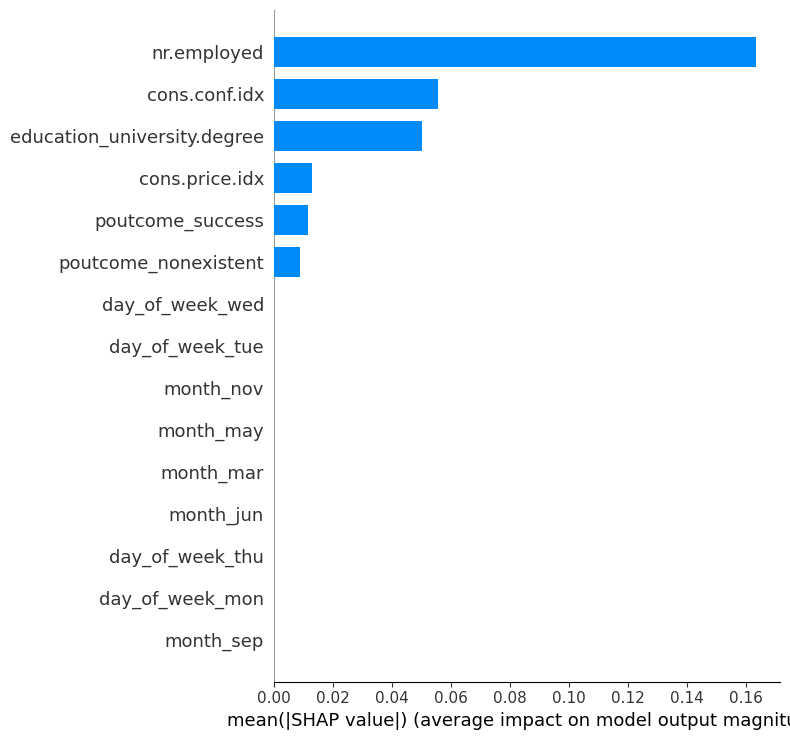

In [17]:
# 1. Створюємо SHAP explainer для DT (max_depth=3)
explainer_dt = shap.TreeExplainer(dt_depth3)
shap_values_dt = explainer_dt.shap_values(X_test)

# 2. Summary Plot — топ ознаки за важливістю
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_dt[:, :, 1],  # клас 1 (yes)
    X_test,
    plot_type='bar',
    max_display=15,
    show=True
)

DT3 використовує лише макроекономічні та демографічні фактори — це дуже логічно і інтерпретовано.

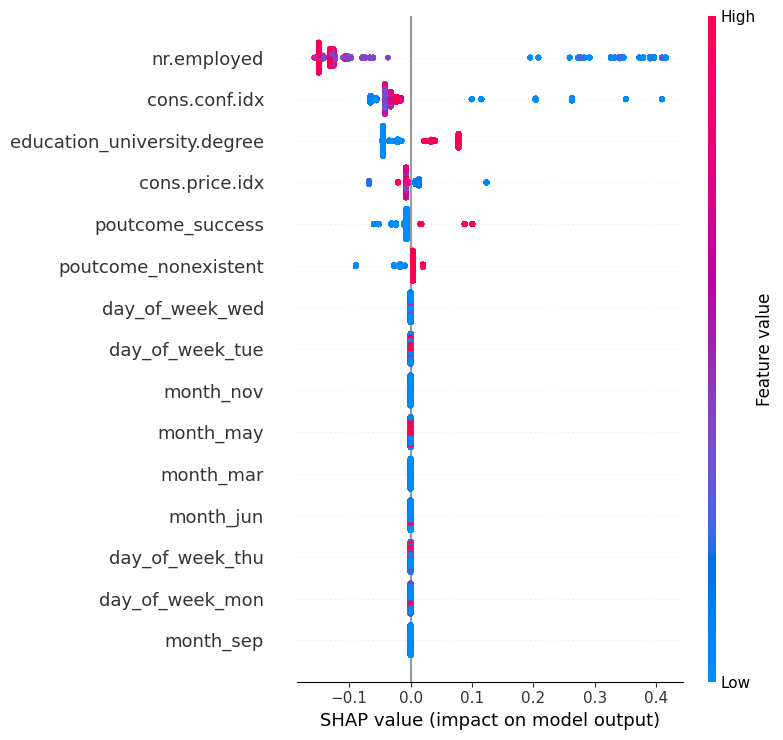

In [36]:
# 3. Beeswarm Plot — напрямок впливу кожної ознаки
shap.summary_plot(
    shap_values_dt[:, :, 1],
    X_test,
    max_display=15
)

<class 'numpy.ndarray'>
(12357, 48)


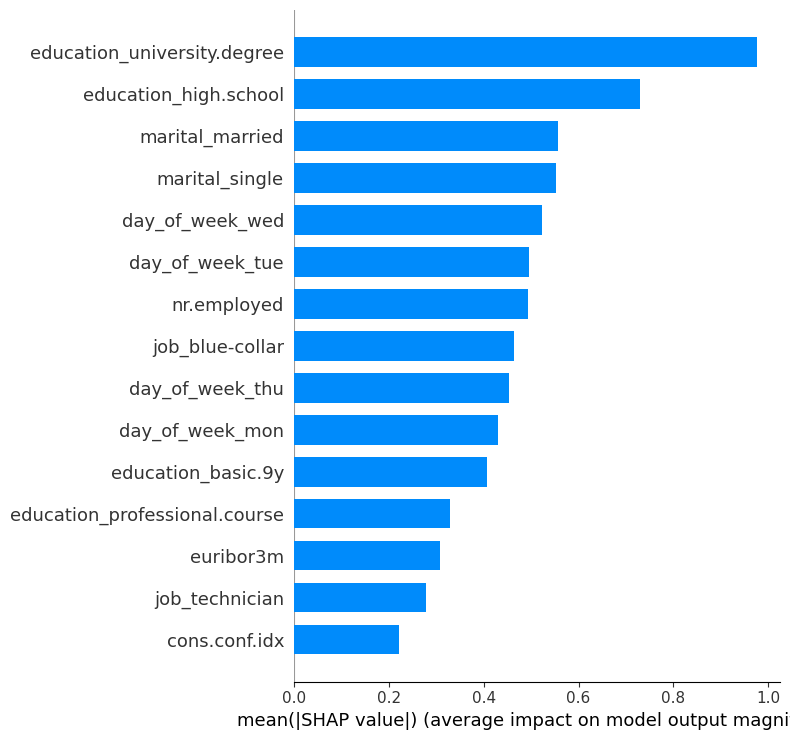

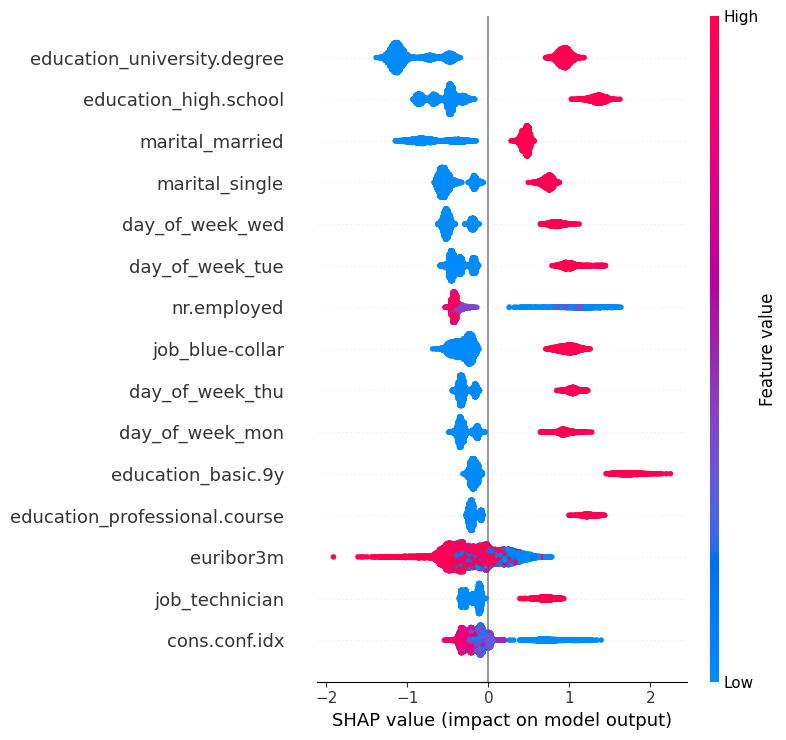

In [37]:
# 1. Explainer для XGBoost
explainer_xgb = shap.TreeExplainer(xgb_tuned)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(type(shap_values_xgb))
print(shap_values_xgb.shape)

# 2. Bar plot — топ 15 ознак
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type='bar',
    max_display=15
)

# 3. Beeswarm — напрямок впливу
shap.summary_plot(
    shap_values_xgb,
    X_test,
    max_display=15
)

In [38]:
#  DT (max_depth=3)
explainer_dt3 = shap.TreeExplainer(dt_depth3)
shap_values_dt3 = explainer_dt3.shap_values(X_test)

# Топ 15 ознак — DT (max_depth=3)
mean_shap_dt3 = np.abs(shap_values_dt3[:, :, 1]).mean(axis=0)
shap_df_dt3 = pd.DataFrame({
    'feature'   : X_test.columns,
    'importance': mean_shap_dt3
}).sort_values('importance', ascending=False).head(15)

print("=== DT (max_depth=3) — Топ 15 ознак ===")
print(shap_df_dt3.to_string(index=False))

print()

# Топ 15 ознак — XGBoost (Bayesian)
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
shap_df_xgb = pd.DataFrame({
    'feature'   : X_test.columns,
    'importance': mean_shap_xgb
}).sort_values('importance', ascending=False).head(15)

print("=== XGBoost (Bayesian) — Топ 15 ознак ===")
print(shap_df_xgb.to_string(index=False))

=== DT (max_depth=3) — Топ 15 ознак ===
                    feature  importance
                nr.employed        0.16
              cons.conf.idx        0.06
education_university.degree        0.05
             cons.price.idx        0.01
           poutcome_success        0.01
       poutcome_nonexistent        0.01
                   previous        0.00
                        age        0.00
                  euribor3m        0.00
              was_contacted        0.00
            job_blue-collar        0.00
           job_entrepreneur        0.00
              job_housemaid        0.00
                      pdays        0.00
               emp.var.rate        0.00

=== XGBoost (Bayesian) — Топ 15 ознак ===
                      feature  importance
  education_university.degree        0.98
        education_high.school        0.73
              marital_married        0.56
               marital_single        0.55
              day_of_week_wed        0.52
              day_of_week

DT3 використовує лише макроекономічні та демографічні фактори — це дуже логічно і інтерпретовано.
Головний макроекономічний індикатор це nr.employed

Індекс споживчої впевненості - cons.conf.idx

Освіта впливає на фінансові рішення - education_university.degree

В XGBoost (Bayesian) більша розгалудженість по ознаках впливу:

На першому місці вища освіта, що дуже логічно. Потім освіта середня, сімейний статус, що теж впливає на відкриття депозиту.

Мені лише не зрозумілі ці дві ознаки: day_of_week_wed (0.52), day_of_week_tue (0.50). - це два робочі дні які як на мене не мають логічного впливу на прийняття рішення про депозит. Але, ці ознаки знаходяться перед ознакою зайнятості (nr.employed), що я вважаю не логічним. Скоріш за все якісь мітки внутрішні банка, а не реальна поведінка клієнтів.

Отже, я зупиняю свій вибір на Decision Tree(max_depth=3).

In [ ]:
# Навчаємо DT з max_depth=3 ще раз дивимось на метрики
dt_depth3 = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_depth3.fit(X_train_res, y_train_res)

dt3_train_roc = round(roc_auc_score(y_train_res, dt_depth3.predict_proba(X_train_res)[:, 1]), 4)
dt3_train_f1  = round(f1_score(y_train_res, dt_depth3.predict(X_train_res)), 4)
print(f"Train ROC-AUC: {dt3_train_roc}")
print(f"Train F1:      {dt3_train_f1}")

# Оцінка на валідації
y_val_pred_dt3  = dt_depth3.predict(X_val)
y_val_proba_dt3 = dt_depth3.predict_proba(X_val)[:, 1]
evaluate_model("Decision Tree (max_depth=3) — Validation", y_val, y_val_pred_dt3, y_val_proba_dt3)

# Оцінка на тесті
y_test_pred_dt3  = dt_depth3.predict(X_test)
y_test_proba_dt3 = dt_depth3.predict_proba(X_test)[:, 1]
evaluate_model("Decision Tree (max_depth=3) — TEST", y_test, y_test_pred_dt3, y_test_proba_dt3)

Train ROC-AUC: 0.7885
Train F1:      0.7027
  Decision Tree (max_depth=3) — Validation
ROC-AUC  : 0.7509
F1-Score : 0.4483
Precision: 0.3549
Recall   : 0.6084

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      6396
           1       0.35      0.61      0.45       812

    accuracy                           0.83      7208
   macro avg       0.65      0.73      0.67      7208
weighted avg       0.88      0.83      0.85      7208

Confusion Matrix:
[[5498  898]
 [ 318  494]]
  Decision Tree (max_depth=3) — TEST
ROC-AUC  : 0.7579
F1-Score : 0.4600
Precision: 0.3677
Recall   : 0.6142

              precision    recall  f1-score   support

           0       0.95      0.87      0.90     10965
           1       0.37      0.61      0.46      1392

    accuracy                           0.84     12357
   macro avg       0.66      0.74      0.68     12357
weighted avg       0.88      0.84      0.85     12357

Confusion Matrix:
[[9495 1470]


Спостереження:

DT (max_depth=3) переважає

Мінімальне перенавчання (різниця Train/Test = 0.03)

Вищий Recall (0.61) — знаходить більше клієнтів

Знайшов 855 потенційних клієнтів

Краща інтерпретованість — лише 3 рівні рішень.

Тобто, ця модель є найкращою для поставленої задачі.

Банку вигідніше знайти більше клієнтів (855) навіть ціною додаткових дзвінків.

Кожен депозит окупає багато дзвінків.

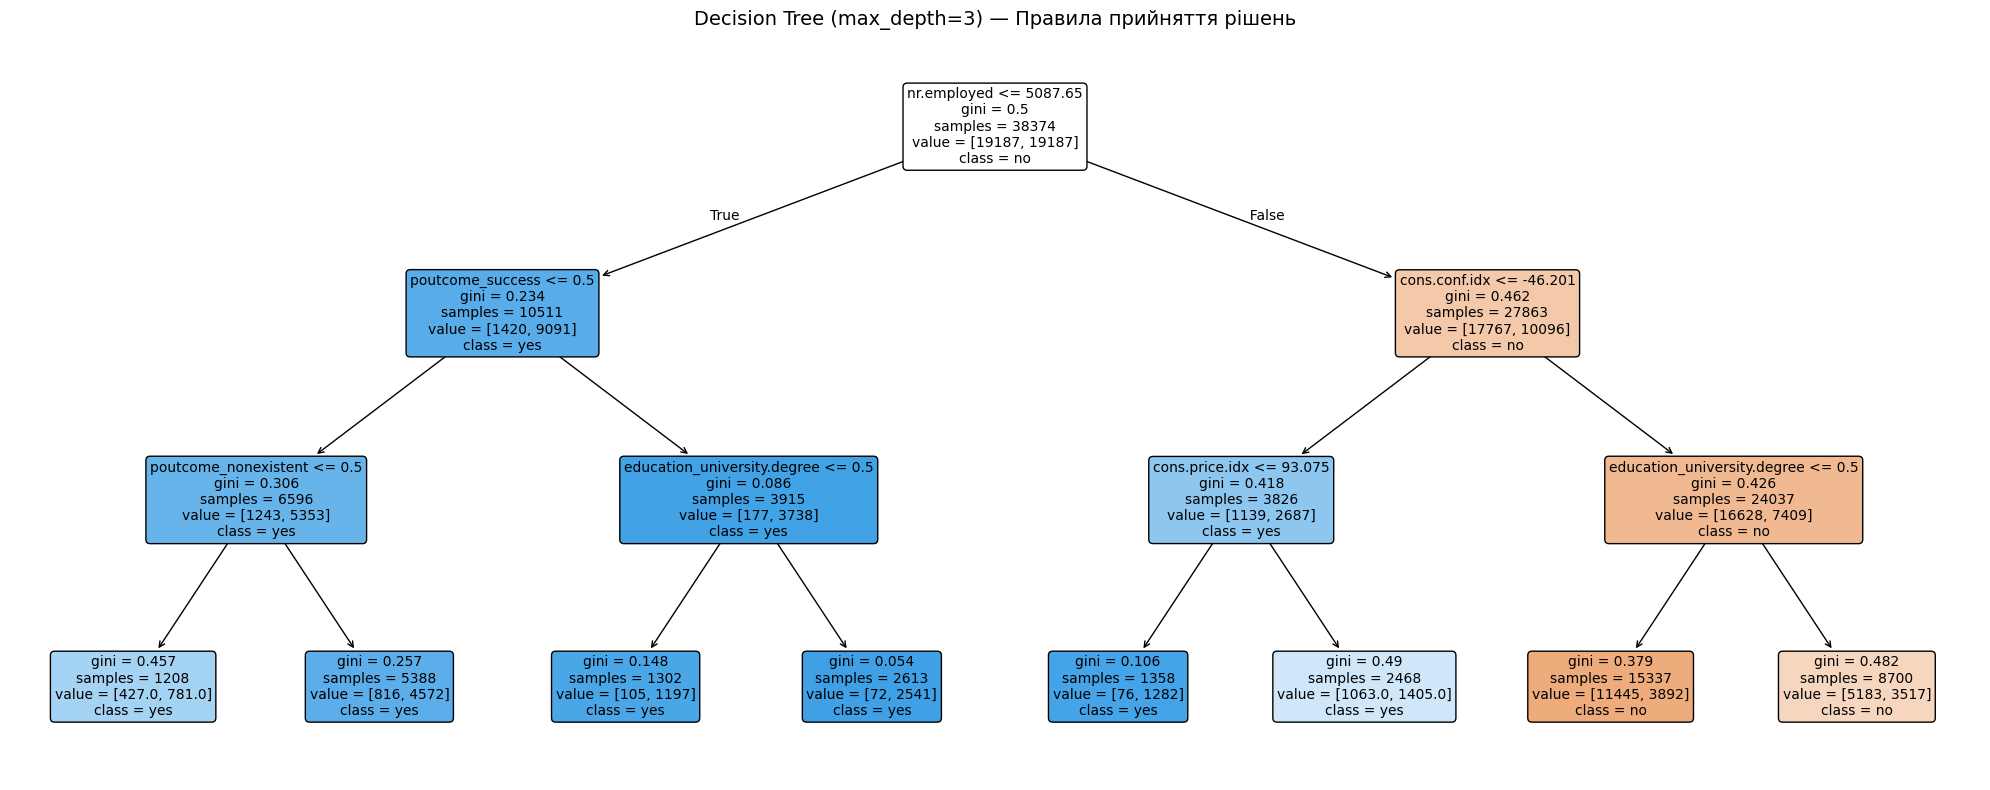

In [39]:
# Опціонально можна подивитись як приймаються рішення в дереві
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plot_tree(
    dt_depth3,
    feature_names=X_test.columns.tolist(),
    class_names=['no', 'yes'],
    filled=True,        # кольорове заповнення
    rounded=True,       # округлені кути
    fontsize=10,
    max_depth=3
)
plt.title('Decision Tree (max_depth=3) — Правила прийняття рішень', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Фінальна таблиця порівняння Val та Test для всіх моделей
test_results = {
    'Модель': [
        'Logistic Regression',
        'kNN',
        'Decision Tree (default)',
        'Decision Tree (max_depth=5)',
        'Decision Tree (max_depth=3)',
        'XGBoost (default)',
        'XGBoost (RandomizedSearch)',
        'XGBoost (Bayesian)'
    ],
    # Validation метрики
    'ROC-AUC Val': [0.7094, 0.7108, 0.6277, 0.7454, 0.7509, 0.7664, 0.7644, 0.7772],
    'F1 Val':      [0.3642, 0.3591, 0.3209, 0.4495, 0.4483, 0.4187, 0.4093, 0.4374],
    'Recall Val':  [0.4089, 0.4347, 0.3805, 0.5616, 0.6084, 0.3744, 0.3571, 0.4175],

    # Test метрики — потрібно порахувати для всіх моделей
    'ROC-AUC Test': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]), 4),
        round(roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_default.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_depth5.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_depth3.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, xgb_default.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, random_xgb_v2.best_estimator_.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:, 1]), 4)
    ],
    'F1 Test': [
        round(f1_score(y_test, lr.predict(X_test_scaled)), 4),
        round(f1_score(y_test, knn.predict(X_test_scaled)), 4),
        round(f1_score(y_test, dt_default.predict(X_test)), 4),
        round(f1_score(y_test, dt_depth5.predict(X_test)), 4),
        round(f1_score(y_test, dt_depth3.predict(X_test)), 4),
        round(f1_score(y_test, xgb_default.predict(X_test)), 4),
        round(f1_score(y_test, random_xgb_v2.best_estimator_.predict(X_test)), 4),
        round(f1_score(y_test, xgb_tuned.predict(X_test)), 4)
    ],
    'Recall Test': [
        round(recall_score(y_test, lr.predict(X_test_scaled)), 4),
        round(recall_score(y_test, knn.predict(X_test_scaled)), 4),
        round(recall_score(y_test, dt_default.predict(X_test)), 4),
        round(recall_score(y_test, dt_depth5.predict(X_test)), 4),
        round(recall_score(y_test, dt_depth3.predict(X_test)), 4),
        round(recall_score(y_test, xgb_default.predict(X_test)), 4),
        round(recall_score(y_test, random_xgb_v2.best_estimator_.predict(X_test)), 4),
        round(recall_score(y_test, xgb_tuned.predict(X_test)), 4)
    ],
}

df_final = pd.DataFrame(test_results)

# Додаємо різницю Val vs Test (чи є перенавчання)
df_final['ROC-AUC різниця'] = (df_final['ROC-AUC Val'] - df_final['ROC-AUC Test']).round(4)

df_final

,Модель,ROC-AUC Val,F1 Val,Recall Val,ROC-AUC Test,F1 Test,Recall Test,ROC-AUC різниця
0,Logistic Regression,0.71,0.36,0.41,0.73,0.39,0.42,-0.03
1,kNN,0.71,0.36,0.43,0.73,0.39,0.47,-0.02
2,Decision Tree (default),0.63,0.32,0.38,0.63,0.32,0.36,0.00
3,Decision Tree (max_depth=5),0.75,0.45,0.56,0.75,0.47,0.57,-0.01
4,Decision Tree (max_depth=3),0.75,0.45,0.61,0.76,0.46,0.61,-0.01
5,XGBoost (default),0.77,0.42,0.37,0.78,0.43,0.38,-0.01
6,XGBoost (RandomizedSearch),0.76,0.41,0.36,0.77,0.43,0.37,-0.01
7,XGBoost (Bayesian),0.78,0.44,0.42,0.79,0.46,0.43,-0.01


Спостереження
Моделі показують себе краще на тесті ніж на валідації.

Моделі не "завчили" валідаційну вибірку
і показують стабільний результат на нових даних. Баланс класів однаковий у всіх трьох вибірках, тому завдяки stratify маємо хороший результат.

Висновок: XGBoost (Bayesian)ROC-AUC 0.79, F1 0.46 - є найвищим показником.

Але врахувавши економічний та бізнес сенс моделі прийняття рішень, запиняємось на моделі DT (max_depth=3)з найкращим Recall 0.61.

# Помилки і робота з ними

Головна проблема — False Negative:
Модель DT3 пропускає клієнтів з найдовшими дзвінками
(середня 822 сек) — це найцінніші клієнти.
Без duration модель не бачить цього сигналу.

Основна причина помилок — відсутність duration у моделі. Клієнти які спілкуються довше (>500 сек) мають конверсію 40% проти 11% середньої. Якщо банк зможе зібрати проксі-ознаки що передбачають тривалість дзвінка (наприклад, попередня історія клієнта), це значно покращить якість моделі.

В іншому випадку я б покращувала б модель XGBoost (Bayesian) або поєднати DT3 + XGBoost для кращого балансу Recall та Precision